# Análise de Estabilidade de Talude — Equilíbrio Limite (Método de Bishop Simplificado)

Este notebook realiza uma análise de estabilidade de taludes por **equilíbrio limite**, usando o **Método de Bishop Simplificado** com superfícies de ruptura **circulares**.

**O usuário informa:**
- As coordenadas (x, y) da linha superficial (perfil) do talude;
- As propriedades do solo: peso específico (γ), coesão (c) e ângulo de atrito (φ).

**O que o notebook calcula:**
- Uma busca (grid search + refinamento numérico) pelo **círculo crítico** de ruptura, isto é, o que fornece o **menor Fator de Segurança (FS)**;
- O FS crítico e o FS de qualquer círculo definido manualmente;
- Gráficos do talude com a superfície de ruptura crítica e um mapa dos FS testados.

> **Simplificações assumidas:** solo homogêneo (uma única camada), superfície de ruptura circular, sem nível d'água / poropressão (u = 0). O código foi estruturado para facilitar extensões (múltiplas camadas, poropressão, sobrecargas, etc.).

## 1. Importação de bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize

%matplotlib inline


## 2. Dados de entrada — Geometria do talude

Informe as coordenadas **(x, y)** da linha superficial do talude, da esquerda para a direita (x crescente), em metros.

Exemplo abaixo: um talude simples com crista em x=0 e pé do talude em x=20 (altura de 10 m, inclinação 2H:1V), com trechos horizontais antes e depois para dar espaço à busca do círculo crítico.

Exemplo Braja Das

x (m), y (m)
0.00, 0.00
-5.38, 0.00
-11.65, 10.00
-18.52, 10.00

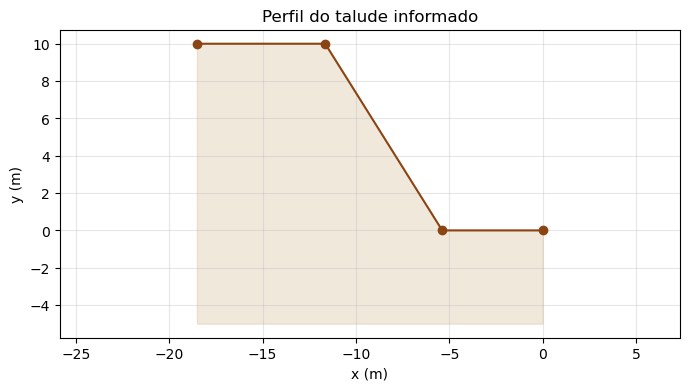

In [2]:
# --- COORDENADAS DA LINHA SUPERFICIAL DO TALUDE (x, y) em metros ---
# Edite esta lista com os pontos do seu perfil, em ordem crescente de x.
superficie = [
    (-18.52, 10.00),   # início do platô superior (crista)
    (-11.65, 10.00),   # crista do talude
    (-5.38, 0.00),   # pé do talude (inclinação 2H:1V)
    (0.00, 0.00),   # trecho horizontal inferior
]

surf_x = np.array([p[0] for p in superficie], dtype=float)
surf_y = np.array([p[1] for p in superficie], dtype=float)

assert np.all(np.diff(surf_x) > 0), "As coordenadas devem ter x estritamente crescente."

plt.figure(figsize=(8, 4))
plt.plot(surf_x, surf_y, "o-", color="saddlebrown")
plt.fill_between(surf_x, surf_y, surf_y.min() - 5, color="tan", alpha=0.3)
plt.title("Perfil do talude informado")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()


### 2.1 Identificação automática da crista e do pé do talude

O código localiza automaticamente a **crista** (ponto mais alto) e o **pé** (ponto mais baixo logo após a crista) do talude a partir das coordenadas informadas. Essa informação é usada apenas para **dimensionar automaticamente a região de busca** do círculo crítico (Seção 6) — ela não limita a forma da superfície de ruptura em si.

> Válido para um talude "simples", com um único trecho descendente entre um platô superior e um platô inferior (como no exemplo). Para geometrias mais complexas (múltiplas bermas, ondulações), ajuste manualmente `x_crest`, `x_toe` e/ou os intervalos de busca da Seção 6.

In [3]:
# indice do ultimo ponto na maior elevacao (crista) e do primeiro ponto na
# menor elevacao encontrado a partir da crista (pe do talude)
i_crest = int(np.max(np.where(surf_y == surf_y.max())[0]))
i_toe = i_crest + int(np.argmin(surf_y[i_crest:]))

x_crest, y_crest = surf_x[i_crest], surf_y[i_crest]
x_toe, y_toe = surf_x[i_toe], surf_y[i_toe]

slope_width = abs(x_toe - x_crest)
slope_height = abs(y_crest - y_toe)
diag = np.hypot(slope_width, slope_height)   # comprimento aproximado da face do talude
margin = 0.25 * slope_width                   # folga permitida para entrada/saida do circulo

print(f"Crista: x={x_crest:.2f} m, y={y_crest:.2f} m")
print(f"Pe do talude: x={x_toe:.2f} m, y={y_toe:.2f} m")
print(f"Altura do talude: {slope_height:.2f} m | Largura da face: {slope_width:.2f} m")


Crista: x=-11.65 m, y=10.00 m
Pe do talude: x=-5.38 m, y=0.00 m
Altura do talude: 10.00 m | Largura da face: 6.27 m


## 3. Dados de entrada — Propriedades do solo

Informe as características do solo (considerado homogêneo nesta versão):

- **γ** — peso específico (kN/m³)
- **c** — coesão (kPa)
- **φ** — ângulo de atrito interno (graus)

In [4]:
# --- PROPRIEDADES DO SOLO ---
gamma = 19.0     # peso específico (kN/m3)
c = 20.0         # coesão (kPa)
phi_deg = 20.0   # ângulo de atrito (graus)

phi_rad = np.radians(phi_deg)

print(f"gamma = {gamma} kN/m3 | c = {c} kPa | phi = {phi_deg} graus")


gamma = 19.0 kN/m3 | c = 20.0 kPa | phi = 20.0 graus


## 4. Funções auxiliares de geometria

- `surface_y(x)`: interpola a altura da superfície do talude em qualquer x;
- `circle_y(x, xc, yc, R)`: altura do arco inferior do círculo de ruptura em x;
- `find_entry_exit(...)`: encontra os pontos onde o círculo de ruptura intercepta a superfície do talude (entrada e saída da massa de ruptura).

In [5]:
def surface_y(x):
    """Altura da superfície do talude em x (interpolação linear)."""
    return np.interp(x, surf_x, surf_y)


def circle_y(x, xc, yc, R):
    """Altura do arco inferior do círculo (centro xc,yc raio R) em x. NaN fora do domínio do círculo."""
    val = R**2 - (x - xc)**2
    with np.errstate(invalid="ignore"):
        return np.where(val >= 0, yc - np.sqrt(np.maximum(val, 0)), np.nan)


def find_entry_exit(xc, yc, R, n_samples=400):
    """
    Encontra as coordenadas x de entrada e saída do círculo de ruptura na
    superfície do talude (pontos onde superficie(x) == circulo(x)).
    Retorna (x_entrada, x_saida) ou None se o círculo não gerar uma
    superfície de ruptura válida.
    """
    dom_min = max(surf_x[0], xc - R)
    dom_max = min(surf_x[-1], xc + R)
    if dom_max - dom_min < 1e-6:
        return None

    xs = np.linspace(dom_min, dom_max, n_samples)
    diff = surface_y(xs) - circle_y(xs, xc, yc, R)

    # precisa haver trecho onde a superficie esta acima do circulo (massa de solo)
    if not np.any(diff > 0):
        return None

    # localizar mudancas de sinal e refinar com brentq
    roots = []
    for i in range(len(xs) - 1):
        d0, d1 = diff[i], diff[i + 1]
        if np.isnan(d0) or np.isnan(d1):
            continue
        if d0 == 0:
            roots.append(xs[i])
        elif d0 * d1 < 0:
            f = lambda x: surface_y(x) - circle_y(x, xc, yc, R)
            try:
                r = brentq(f, xs[i], xs[i + 1])
                roots.append(r)
            except ValueError:
                continue

    if len(roots) < 2:
        return None

    x_entry, x_exit = min(roots), max(roots)
    if x_exit - x_entry < 1e-3:
        return None

    # verificar que ha material entre entrada e saida (circulo abaixo da superficie)
    x_mid = 0.5 * (x_entry + x_exit)
    if surface_y(x_mid) - circle_y(x_mid, xc, yc, R) <= 0:
        return None

    # a superficie de ruptura deve atravessar essencialmente toda a face do
    # talude (da crista ao pe, com alguma folga), evitando "fatias" rasas e
    # sem sentido fisico que tocam apenas o platô superior ou inferior
    if x_entry > x_crest + margin or x_exit < x_toe - margin:
        return None

    return x_entry, x_exit


## 5. Geração das fatias (slices) e cálculo do FS — Método de Bishop Simplificado

Para um círculo de ruptura (xc, yc, R), a massa deslizante é dividida em fatias verticais. Para cada fatia *i*:

- largura `b_i`, altura média `h_i`, ângulo da base `α_i` (sin α_i = (xc − x_i) / R, positivo no sentido da saída do talude)
- peso `W_i = γ · b_i · h_i`

O Fator de Segurança pelo método de **Bishop Simplificado** é calculado iterativamente:

$$
FS = \frac{\sum \dfrac{c\, b_i + W_i \tan\varphi}{m_{\alpha,i}}}{\sum W_i \sin\alpha_i}
\qquad\text{onde}\qquad
m_{\alpha,i} = \cos\alpha_i + \frac{\sin\alpha_i \tan\varphi}{FS}
$$

começando de um FS inicial (Fellenius) e iterando até convergência.

In [6]:
def build_slices(xc, yc, R, n_slices=30):
    """
    Constrói as fatias entre a entrada e a saída do círculo de ruptura.
    Retorna dict com arrays b, h, alpha, W, x_mid — ou None se inválido.
    """
    entry_exit = find_entry_exit(xc, yc, R)
    if entry_exit is None:
        return None
    x_entry, x_exit = entry_exit

    edges = np.linspace(x_entry, x_exit, n_slices + 1)
    x_left, x_right = edges[:-1], edges[1:]
    x_mid = 0.5 * (x_left + x_right)
    b = x_right - x_left

    y_top = surface_y(x_mid)
    y_bot = circle_y(x_mid, xc, yc, R)

    if np.any(np.isnan(y_bot)):
        return None

    h = y_top - y_bot
    if np.any(h <= 0):
        return None

    # convencao: sin(alpha) = (xc - x)/R, positivo do lado da saida (pe) do
    # talude — necessario para que o momento motor Sum(W*sin(alpha)) resulte
    # positivo quando o centro do circulo fica acima/a favor da massa instavel
    arg = np.clip((xc - x_mid) / R, -1.0, 1.0)
    alpha = np.arcsin(arg)  # rad

    W = gamma * b * h

    return {"b": b, "h": h, "alpha": alpha, "W": W, "x_mid": x_mid,
            "x_entry": x_entry, "x_exit": x_exit}


def bishop_fs(slices, phi_rad, c, fs_init=1.0, tol=1e-5, max_iter=100):
    """
    Calcula o FS pelo método de Bishop Simplificado (iterativo) para um
    conjunto de fatias. Retorna (FS, convergiu:bool).
    """
    b, h, alpha, W = slices["b"], slices["h"], slices["alpha"], slices["W"]
    tan_phi = np.tan(phi_rad)

    denom = np.sum(W * np.sin(alpha))
    if denom <= 0:
        return np.nan, False

    fs = fs_init
    for _ in range(max_iter):
        m_alpha = np.cos(alpha) + np.sin(alpha) * tan_phi / fs
        if np.any(m_alpha < 0.2):  # instabilidade numerica tipica do metodo
            return np.nan, False
        numer = np.sum((c * b + W * tan_phi) / m_alpha)
        fs_new = numer / denom
        if abs(fs_new - fs) < tol:
            return fs_new, True
        fs = fs_new
    return fs, False


def fs_for_circle(xc, yc, R, n_slices=30):
    """Calcula o FS (Bishop) para um círculo definido por (xc, yc, R). NaN se inválido."""
    slices = build_slices(xc, yc, R, n_slices=n_slices)
    if slices is None:
        return np.nan
    fs, converged = bishop_fs(slices, phi_rad, c)
    if not converged:
        return np.nan
    return fs


## 6. Busca do círculo crítico (menor FS)

A busca é feita em duas etapas:

1. **Grid search**: varre uma malha de centros `(xc, yc)` e raios `R`, calculando o FS de cada círculo válido;
2. **Refinamento**: usa otimização numérica (Nelder-Mead) a partir do melhor ponto do grid para refinar `(xc, yc, R)` e encontrar o FS mínimo com mais precisão.

Os intervalos de busca são estimados automaticamente a partir da geometria do talude, mas podem ser ajustados manualmente abaixo.

In [7]:
# --- Intervalos de busca (ajuste se necessário) ---
# Centrados na face do talude (crista/pé identificados na Seção 2.1), que é
# onde circulos de ruptura fisicamente plausiveis se concentram.
n_xc, n_yc, n_R = 22, 16, 22   # resolução do grid (aumente para maior precisão, custa mais tempo)

xc_vals = np.linspace(x_crest - 0.5 * slope_width, x_toe + 1.5 * slope_width, n_xc)
yc_vals = np.linspace(y_crest + 0.1 * diag, y_crest + 2.5 * diag, n_yc)
R_vals = np.linspace(0.5 * diag, 3.0 * diag, n_R)

n_slices_grid = 20  # menos fatias no grid (mais rápido); refina depois

melhor_fs = np.inf
melhor_circ = None
resultados_grid = []  # (xc, yc, R, fs) para visualização

for xc in xc_vals:
    for yc in yc_vals:
        for R in R_vals:
            fs = fs_for_circle(xc, yc, R, n_slices=n_slices_grid)
            if np.isfinite(fs) and fs > 0:
                resultados_grid.append((xc, yc, R, fs))
                if fs < melhor_fs:
                    melhor_fs = fs
                    melhor_circ = (xc, yc, R)

if melhor_circ is None:
    raise RuntimeError(
        "Nenhum círculo válido foi encontrado nos intervalos de busca. "
        "Ajuste xc_vals / yc_vals / R_vals."
    )

print(f"Melhor resultado do grid search: FS = {melhor_fs:.4f}")
print(f"Círculo: xc = {melhor_circ[0]:.2f} m | yc = {melhor_circ[1]:.2f} m | R = {melhor_circ[2]:.2f} m")
print(f"Círculos válidos testados: {len(resultados_grid)} de {n_xc*n_yc*n_R}")


Melhor resultado do grid search: FS = 1.0817
Círculo: xc = -0.45 m | yc = 14.96 m | R = 15.74 m
Círculos válidos testados: 62 de 7744


In [8]:
# --- Refinamento numérico a partir do melhor ponto do grid ---
def objetivo(params):
    xc, yc, R = params
    fs = fs_for_circle(xc, yc, R, n_slices=50)
    if not np.isfinite(fs):
        return 1e3  # penaliza círculos inválidos
    return fs

res = minimize(objetivo, x0=np.array(melhor_circ), method="Nelder-Mead",
                options={"xatol": 1e-3, "fatol": 1e-5, "maxiter": 500})

xc_crit, yc_crit, R_crit = res.x
fs_crit = objetivo(res.x)

print("=== Círculo crítico (refinado) ===")
print(f"xc = {xc_crit:.3f} m | yc = {yc_crit:.3f} m | R = {R_crit:.3f} m")
print(f"Fator de Segurança crítico (Bishop Simplificado): FS = {fs_crit:.4f}")


=== Círculo crítico (refinado) ===
xc = -0.465 m | yc = 15.014 m | R = 15.798 m
Fator de Segurança crítico (Bishop Simplificado): FS = 1.0796


## 7. Resultados — Gráficos

### 7.1 Talude com a superfície de ruptura crítica

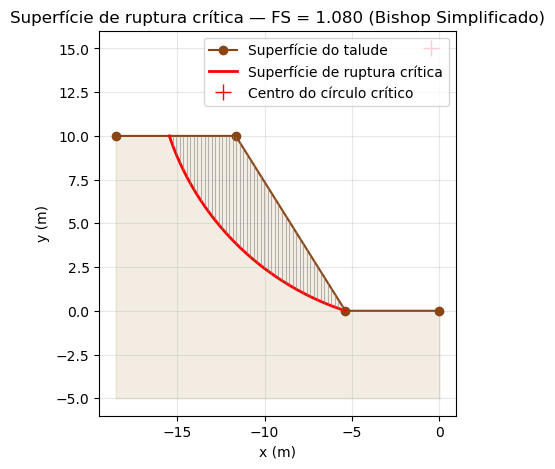

In [9]:
slices_crit = build_slices(xc_crit, yc_crit, R_crit, n_slices=50)
x_entry, x_exit = slices_crit["x_entry"], slices_crit["x_exit"]

xs_arc = np.linspace(x_entry, x_exit, 200)
ys_arc = circle_y(xs_arc, xc_crit, yc_crit, R_crit)

plt.figure(figsize=(9, 5))
plt.plot(surf_x, surf_y, "o-", color="saddlebrown", label="Superfície do talude")
plt.fill_between(surf_x, surf_y, surf_y.min() - 5, color="tan", alpha=0.25)
plt.plot(xs_arc, ys_arc, "r-", lw=2, label="Superfície de ruptura crítica")
plt.plot(xc_crit, yc_crit, "r+", ms=12, label="Centro do círculo crítico")

# desenha as fatias
for xl, xr in zip(np.linspace(x_entry, x_exit, 51)[:-1], np.linspace(x_entry, x_exit, 51)[1:]):
    ytop = surface_y(xl)
    ybot = circle_y(np.array([xl]), xc_crit, yc_crit, R_crit)[0]
    plt.plot([xl, xl], [ybot, ytop], color="gray", lw=0.4)

plt.gca().set_aspect("equal", adjustable="box")
plt.title(f"Superfície de ruptura crítica — FS = {fs_crit:.3f} (Bishop Simplificado)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()


### 7.2 Mapa dos centros testados (menor FS por posição do centro)

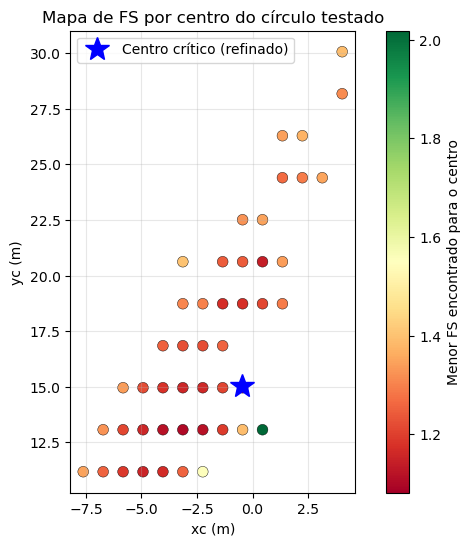

In [10]:
# Para cada combinação (xc, yc) testada, guarda o menor FS entre os raios avaliados
import collections

melhor_por_centro = {}
for xc, yc, R, fs in resultados_grid:
    key = (xc, yc)
    if key not in melhor_por_centro or fs < melhor_por_centro[key]:
        melhor_por_centro[key] = fs

xs_c = np.array([k[0] for k in melhor_por_centro])
ys_c = np.array([k[1] for k in melhor_por_centro])
fs_c = np.array([v for v in melhor_por_centro.values()])

plt.figure(figsize=(8, 6))
sc = plt.scatter(xs_c, ys_c, c=fs_c, cmap="RdYlGn", s=60, edgecolor="k", linewidth=0.3)
plt.colorbar(sc, label="Menor FS encontrado para o centro")
plt.plot(xc_crit, yc_crit, "b*", ms=18, label="Centro crítico (refinado)")
plt.title("Mapa de FS por centro do círculo testado")
plt.xlabel("xc (m)")
plt.ylabel("yc (m)")
plt.legend()
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.3)
plt.show()


## 8. Avaliar um círculo específico (opcional)

Use esta célula para calcular o FS de um círculo definido manualmente (por exemplo, para comparar com uma superfície de ruptura observada em campo).

In [11]:
# Exemplo: defina manualmente xc, yc, R e avalie o FS
xc_manual = -5.38 # m
yc_manual = 11.98 # m
R_manual = 13.13 # m
n_fatias = 9

fs_manual = fs_for_circle(xc_manual, yc_manual, R_manual, n_slices=n_fatias)
print(f"FS (Bishop) para o círculo xc={xc_manual:.2f}, yc={yc_manual:.2f}, R={R_manual:.2f}: {fs_manual:.4f}")


FS (Bishop) para o círculo xc=-5.38, yc=11.98, R=13.13: 1.3534


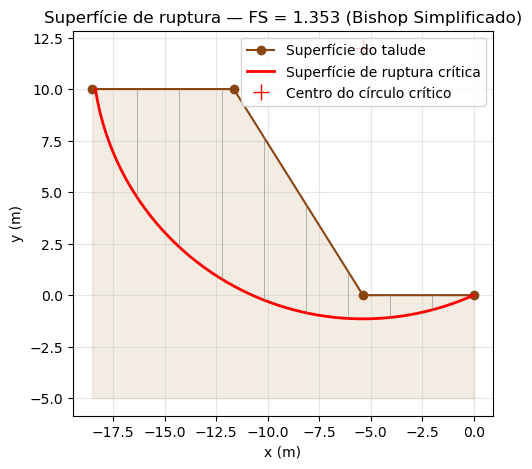

In [12]:
slices_crit = build_slices(xc_manual, yc_manual, R_manual, n_slices=n_fatias)
x_entry, x_exit = slices_crit["x_entry"], slices_crit["x_exit"]

xs_arc = np.linspace(x_entry, x_exit, 200)
ys_arc = circle_y(xs_arc, xc_manual, yc_manual, R_manual)

plt.figure(figsize=(9, 5))
plt.plot(surf_x, surf_y, "o-", color="saddlebrown", label="Superfície do talude")
plt.fill_between(surf_x, surf_y, surf_y.min() - 5, color="tan", alpha=0.25)
plt.plot(xs_arc, ys_arc, "r-", lw=2, label="Superfície de ruptura crítica")
plt.plot(xc_manual, yc_manual, "r+", ms=12, label="Centro do círculo crítico")

# desenha as fatias
for xl, xr in zip(np.linspace(x_entry, x_exit, n_fatias+1)[:-1], np.linspace(x_entry, x_exit, n_fatias+1)[1:]):
    ytop = surface_y(xl)
    ybot = circle_y(np.array([xl]), xc_manual, yc_manual, R_manual)[0]
    plt.plot([xl, xl], [ybot, ytop], color="gray", lw=0.4)

plt.gca().set_aspect("equal", adjustable="box")
plt.title(f"Superfície de ruptura — FS = {fs_manual:.3f} (Bishop Simplificado)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()


## 9. Resumo dos resultados

In [13]:
print("="*50)
print("RESUMO DA ANALISE DE ESTABILIDADE DE TALUDE")
print("="*50)
print(f"Metodo: Bishop Simplificado (superficie circular)")
print(f"Solo: gamma = {gamma} kN/m3 | c = {c} kPa | phi = {phi_deg} graus")
print("-"*50)
print(f"Circulo critico:")
print(f"  xc = {xc_crit:.3f} m")
print(f"  yc = {yc_crit:.3f} m")
print(f"  R  = {R_crit:.3f} m")
print(f"Fator de Seguranca minimo: FS = {fs_crit:.3f}")
print("-"*50)
if fs_crit < 1.0:
    print("=> Talude INSTAVEL (FS < 1.0)")
elif fs_crit < 1.5:
    print("=> Talude com FS abaixo do minimo usual de projeto (1.5)")
else:
    print("=> Talude considerado ESTAVEL (FS >= 1.5)")
print("="*50)


RESUMO DA ANALISE DE ESTABILIDADE DE TALUDE
Metodo: Bishop Simplificado (superficie circular)
Solo: gamma = 19.0 kN/m3 | c = 20.0 kPa | phi = 20.0 graus
--------------------------------------------------
Circulo critico:
  xc = -0.465 m
  yc = 15.014 m
  R  = 15.798 m
Fator de Seguranca minimo: FS = 1.080
--------------------------------------------------
=> Talude com FS abaixo do minimo usual de projeto (1.5)
